## Exploración inicial

#### Pequeño experimento previo

Antes de entrar de lleno a trabajar con los datos verídicos, hacemos un pequeño experimento visual del porque es aconsejable trabajar con rendimientos logarítmicos.

1. Vemos como los rendimientos logarítmicos cumplen aditividad, mientras los simples no.
2. Se observa como en un caso de rendimiento nulo, el rendimiento logarítimico es simetrico ya que nos devuelve 0 como rendimiento, mientras el simple no lo es.

In [5]:
import numpy as np

# Precios inventados de prueba
precios = np.array([100.0, 105.0, 99.75, 108.0, 102.60])

# Rendimientos simples y logarítmicos
simple = precios[1:] / precios[:-1] - 1
log_r  = np.log(precios[1:]) - np.log(precios[:-1])

print("Rendimientos simples :", np.round(simple, 6))
print("Rendimientos log     :", np.round(log_r,  6))

# --- Aditividad ---
total_real = precios[-1] / precios[0] - 1
print("\nRendimiento total real           :", round(total_real, 6))
print("Suma de los simples (INCORRECTO) :", round(simple.sum(), 6))
print("exp(suma de los log) - 1 (BIEN)  :", round(np.exp(log_r.sum()) - 1, 6))

# --- Simetría ---
precios_2 = np.array([100.0, 150.0, 100.0])
simple_2 = precios_2[1:] / precios_2[:-1] - 1
log_2 = np.diff(np.log(precios_2))
print("\n100 -> 150 -> 100")
print("simples:", np.round(simple_2, 4), " suma:", round(simple_2.sum(), 4))
print("log    :", np.round(log_2, 4), " suma:", round(log_2.sum(), 4))

Rendimientos simples : [ 0.05     -0.05      0.082707 -0.05    ]
Rendimientos log     : [ 0.04879  -0.051293  0.079464 -0.051293]

Rendimiento total real           : 0.026
Suma de los simples (INCORRECTO) : 0.032707
exp(suma de los log) - 1 (BIEN)  : 0.026

100 -> 150 -> 100
simples: [ 0.5    -0.3333]  suma: 0.1667
log    : [ 0.4055 -0.4055]  suma: 0.0


## Carga de datos

Primero de todo necesitamos ejecutar ciertas funciones del archivo data.py desde este notebook. Como no estan al mismo nivel, necesitamos subir a la raíz del proyecto para poder cargar dichas funciones.

Finalmente ejecutamos la funcion cargar_precios

In [6]:
# Jupyter arranca en notebooks/, así que Python no ve el paquete src/.

import sys
from pathlib import Path

# Añadimos la raíz del proyecto a la ruta de búsqueda de módulos.
RAIZ = Path.cwd().parent
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from src.data import cargar_precios

precios = cargar_precios()
precios.tail()

[data] Caché local: GSPC_2000-01-01_2026-09-01.csv


,Close,High,Low,Open,Volume
Date,,,,,
2026-08-25,7677.279785,7686.109863,7650.919922,7676.660156,4260240000
2026-08-26,7675.700195,7690.729980,7657.410156,7666.879883,4100600000
2026-08-27,7730.990234,7741.270020,7689.890137,7710.339844,4362240000
2026-08-28,7711.759766,7771.479980,7700.910156,7735.169922,4297560000
2026-08-31,7686.140137,7697.520020,7665.060059,7697.520020,5386090000


Observamos como los datos no contienen niguna anomalia. El número de filas es correcto, ya uqe equivalandrían a unas 252 sesiones por año. El rango es correcto, sin duplicados y sin NaN. 

In [7]:
print("Filas:", len(precios))
print("Rango:", precios.index.min().date(), "→", precios.index.max().date())
print("Índice ordenado:", precios.index.is_monotonic_increasing)
print("Fechas duplicadas:", precios.index.has_duplicates)
print("NaN por columna:\n", precios.isna().sum())
print("\nSesiones por año:\n", precios.index.year.value_counts().sort_index())

Filas: 6705
Rango: 2000-01-03 → 2026-08-31
Índice ordenado: True
Fechas duplicadas: False
NaN por columna:
 Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Sesiones por año:
 Date
2000    252
2001    248
2002    252
2003    252
2004    252
2005    252
2006    251
2007    251
2008    253
2009    252
2010    252
2011    252
2012    250
2013    252
2014    252
2015    252
2016    252
2017    251
2018    251
2019    252
2020    253
2021    252
2022    251
2023    250
2024    252
2025    250
2026    166
Name: count, dtype: int64


## Construcción del dataset

Llamamos a la función construir_dataset  y hacemos un head para mostrar el dataframe obtenido.

In [8]:
from src.features import construir_dataset

df = construir_dataset()
df.head()

[data] Caché local: GSPC_2000-01-01_2026-09-01.csv
[features] 6705 filas -> 6678 tras eliminar NaN
[features] Guardado en C:\Users\Victor\Desktop\Victor\Matematicas\neuro-fuzzy-volatility-forecasting\data\processed\dataset.csv


,close,r,rv_1,rv_5,rv_22,ret_5,y,log_rv_1,log_rv_5,log_rv_22,log_y
Date,,,,,,,,,,,
2000-02-03,1424.969971,0.011185,0.177562,0.286819,0.249093,0.018708,0.174558,-1.728436,-1.248903,-1.389930,-1.745500
2000-02-04,1424.369995,-0.000421,0.006685,0.207867,0.211041,0.046127,0.230427,-5.007846,-1.570857,-1.555705,-1.467820
2000-02-07,1424.239990,-0.000091,0.001449,0.109309,0.210941,0.021131,0.230877,-6.536901,-2.213577,-1.556178,-1.465870
2000-02-08,1441.719971,0.012198,0.193645,0.117539,0.214919,0.022758,0.222705,-1.641728,-2.140988,-1.537496,-1.501909
2000-02-09,1411.709961,-0.021035,0.333922,0.190041,0.207543,0.001836,0.180702,-1.096847,-1.660517,-1.572416,-1.710905


#### Partición del dataset

Se observan los intervalos seleccionados con el número de registros para cada uno.
Además se corrobora que no tenemos fuga de información. También se normalizan los datos para el correcto funcionamiento del modelo.

El dataset esta listo para explorar y modelar.

In [9]:
from src.splits import particionar, normalizar, verificar_sin_fuga

partes = particionar(df)
verificar_sin_fuga(partes)
partes_norm, est = normalizar(partes)

[splits] train  :  3998 filas  (2000-02-03 → 2015-12-23)
[splits] val    :  1001 filas  (2016-01-04 → 2019-12-23)
[splits] test   :  1669 filas  (2020-01-02 → 2026-08-24)
[splits] estres :    52 filas  (2020-02-18 → 2020-04-30)
[splits] Sin fuga. Huecos de 12 y 10 días naturales en las fronteras.


Guardamos el siguiente output como resumen de lo conseguido hasta este punto.

- Intervalos de la partición, con la volatilidad media de cada uno. Notese la partición estres
- Medias normalizadas. Que no sea 0 en cada partición corrobora que no hemos normalizado cada conjunto por separado

In [10]:
import pandas as pd

# Tabla resumen de la partición
resumen = pd.DataFrame({
    nombre: {
        "filas": len(p),
        "desde": p.index.min().date(),
        "hasta": p.index.max().date(),
        "vol. media": round(p["y"].mean(), 4),
    }
    for nombre, p in partes.items()
}).T
print(resumen, "\n")

# Media y desviación tras normalizar: train debe dar ~0 y ~1;
# val y test NO, y eso es lo correcto (usan los estadísticos de train).
for nombre in ["train", "val", "test"]:
    m = partes_norm[nombre][["log_rv_1", "log_rv_5", "log_rv_22"]].mean()
    print(f"{nombre}: medias normalizadas = {m.round(3).values}")

       filas       desde       hasta vol. media
train   3998  2000-02-03  2015-12-23     0.1639
val     1001  2016-01-04  2019-12-23     0.1064
test    1669  2020-01-02  2026-08-24     0.1601
estres    52  2020-02-18  2020-04-30     0.5911 

train: medias normalizadas = [-0.  0. -0.]
val: medias normalizadas = [-0.365 -0.735 -0.783]
test: medias normalizadas = [ 0.003 -0.034 -0.009]


Imagen para la memoria que muestra de un vistazo la volatilidad a 5 días junto a las particiones. Se observa como la partición es cronologica y como el periodo de estrés es un pico aislado.

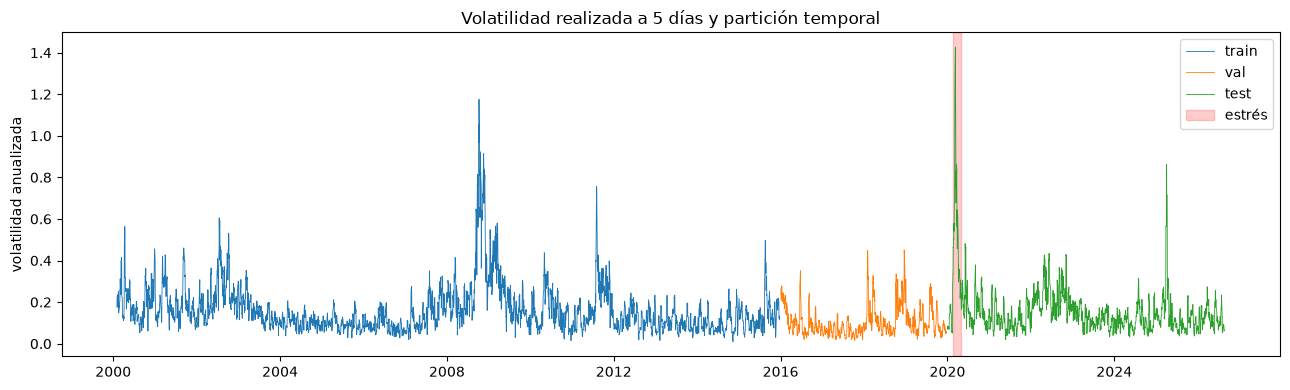

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 4))
colores = {"train": "tab:blue", "val": "tab:orange", "test": "tab:green"}
for nombre, color in colores.items():
    p = partes[nombre]
    ax.plot(p.index, p["y"], color=color, lw=0.6, label=nombre)

e = partes["estres"]
ax.axvspan(e.index.min(), e.index.max(), color="red", alpha=0.2, label="estrés")
ax.set_title("Volatilidad realizada a 5 días y partición temporal")
ax.set_ylabel("volatilidad anualizada")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/particion_temporal.png", dpi=150)
plt.show()

## Exploración

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

# Iremos guardando las figuras en results/figures, que es un subdirectorio de resultados.
FIG = "../results/figures"

# Atajo para capturar la columna de rendimientos como serie
# y ponerle nombre corto.
r = df["r"]

A continuación se muestra una gráfica en donde se muestra el precio del cierre en escala logarítmica, y los rendimientos logarítmicos diarios. Se observa como la anchura de la segunda gráfica no es constante; se ensancha en periodos estresantes (2008 crisis, 2020 Covid), y se estrecha en los periodos tranuilos.

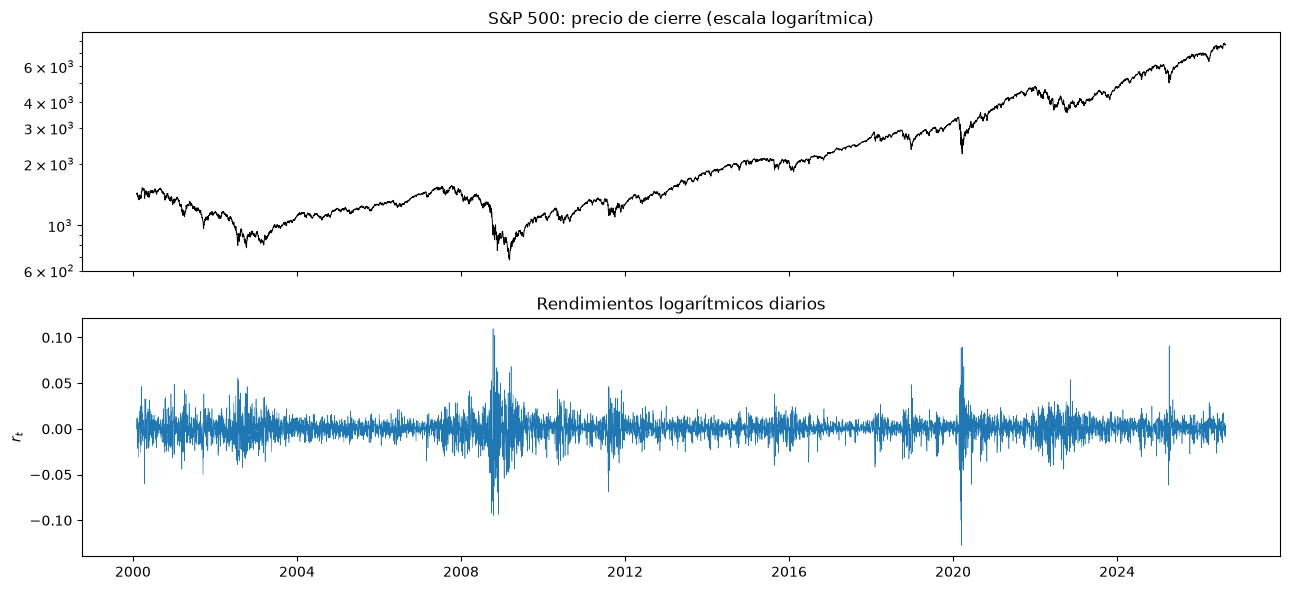

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(df.index, df["close"], lw=0.7, color="black")
axes[0].set_yscale("log")   # escala log: el crecimiento compuesto se ve lineal
axes[0].set_title("S&P 500: precio de cierre (escala logarítmica)")

axes[1].plot(df.index, r, lw=0.4, color="tab:blue")
axes[1].set_title("Rendimientos logarítmicos diarios")
axes[1].set_ylabel("$r_t$")

plt.tight_layout()
plt.savefig(f"{FIG}/serie_precios_rendimientos.png", dpi=150)
plt.show()

A continuación observamos la autocorrelación entre los rendimientos $r_t$ y los $r_t^2$. El resultado es el esperado, tal y como se comento en la sección Notas, E.03. Se observa como en la primera grafica, la ACF es practicamente 0 desde el principio; el signo del movimiento de mañana no se puede anticipar, en cambio como se observa en la gráfica de la derecha la magnitud si es predecible. Además otro dato importante es la observación de la memoria a largo plazo. Tal y como se comento en la nota mencionada, se utilizara la cascada de Corsi utilizando una suma de tres componentes con memoria corta.

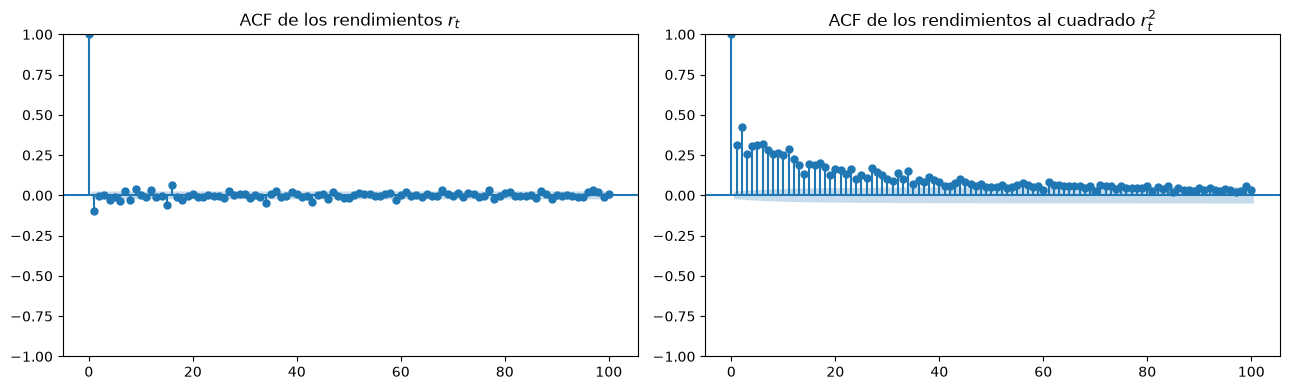

ACF de r  en lags 1,5,22,100: [-0.099 -0.011 -0.009  0.01 ]
ACF de r² en lags 1,5,22,100: [0.314 0.312 0.133 0.035]


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_acf(r.dropna(), lags=100, ax=axes[0], alpha=0.05)
axes[0].set_title("ACF de los rendimientos $r_t$")

plot_acf((r ** 2).dropna(), lags=100, ax=axes[1], alpha=0.05)
axes[1].set_title("ACF de los rendimientos al cuadrado $r_t^2$")

plt.tight_layout()
plt.savefig(f"{FIG}/acf_rendimientos.png", dpi=150)
plt.show()

# Valores numéricos para citar en la memoria
from statsmodels.tsa.stattools import acf
print("ACF de r  en lags 1,5,22,100:", acf(r.dropna(), nlags=100)[[1,5,22,100]].round(3))
print("ACF de r² en lags 1,5,22,100:", acf((r**2).dropna(), nlags=100)[[1,5,22,100]].round(3))

A continuación se muestra claramente como en el caso del cálculo de la volatilidad de instrumentos financieros no siguen una distribución normal. Se observa como cuando la normal (curva roja) se desploma, aún tenemos barras azules presentes. Es decir, hay días extremos que la normal declara imposibles. El Q-Q nos dice lo mismo de otra forma: si los datos fueran normales, los puntos caerían sobre la linea roja. En el centro se observa que lo hacen, pero en los extremos se curvan hacia arriba a la derecha y hacia abajo a la izquierda.

Es decir, los rendimientos son claramente no normales con colas mucho más pesadas que lo que la normal admite. O dicho de otra manera, los sucesos extremos son mucho más frecuentes de lo que la normal admite.

De aquí ya podemos extraer dos conclusiones iniciales:
1. La decisión de entrenar con escala logarítmica es correcta
2. Sin llegar a realizar aún ningun modelo, ya podemos predecir que el modelo GARCH no será bueno ya que asume normalidad

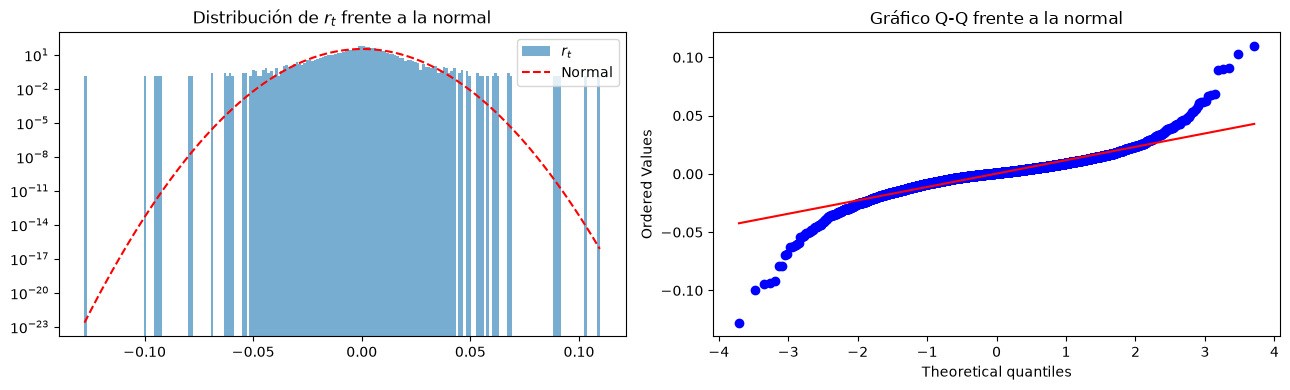

Exceso de curtosis: 10.74   (normal = 0)
Asimetría: -0.35   (normal = 0)
Jarque-Bera: 32148, p-valor = 0.00e+00
Peor día: -0.1277 = 10.5 desviaciones típicas


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma frente a la normal ajustada
axes[0].hist(r.dropna(), bins=200, density=True, alpha=0.6, label="$r_t$")
x = np.linspace(r.min(), r.max(), 500)
axes[0].plot(x, stats.norm.pdf(x, r.mean(), r.std()), "r--", label="Normal")
axes[0].set_yscale("log")   # sin log, las colas son invisibles
axes[0].set_title("Distribución de $r_t$ frente a la normal")
axes[0].legend()

# Gráfico cuantil-cuantil
stats.probplot(r.dropna(), dist="norm", plot=axes[1])
axes[1].set_title("Gráfico Q-Q frente a la normal")

plt.tight_layout()
plt.savefig(f"{FIG}/colas_pesadas.png", dpi=150)
plt.show()

print(f"Exceso de curtosis: {r.kurtosis():.2f}   (normal = 0)")
print(f"Asimetría: {r.skew():.2f}   (normal = 0)")
jb, p = stats.jarque_bera(r.dropna())
print(f"Jarque-Bera: {jb:.0f}, p-valor = {p:.2e}")
peor = r.min()
print(f"Peor día: {peor:.4f} = {abs(peor)/r.std():.1f} desviaciones típicas")

Obbservamos las distribuciones de la variable predictora y, versus la variable predictora en escala logarítmica. Esta es la evidencia empírica de entrenar con escala logarítmica

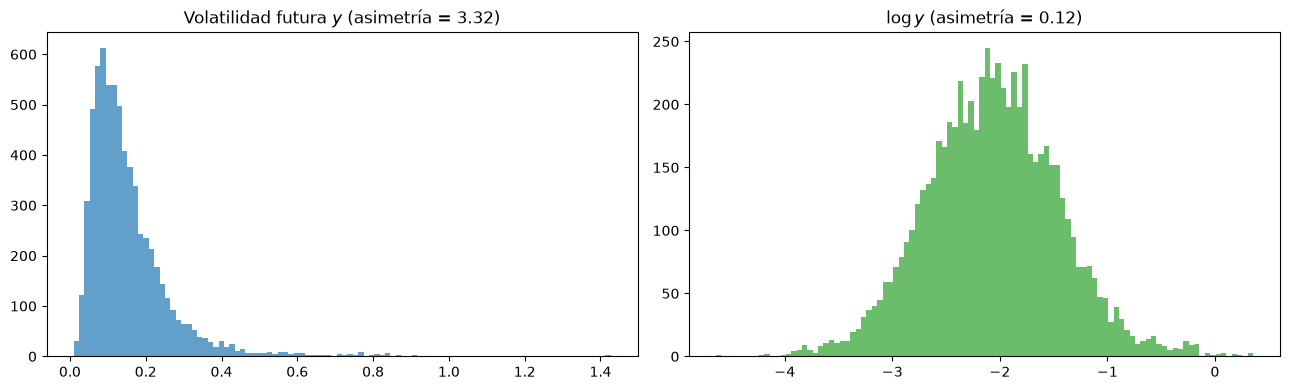

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["y"], bins=100, color="tab:blue", alpha=0.7)
axes[0].set_title(f"Volatilidad futura $y$ (asimetría = {df['y'].skew():.2f})")

axes[1].hist(df["log_y"], bins=100, color="tab:green", alpha=0.7)
axes[1].set_title(f"$\\log y$ (asimetría = {df['log_y'].skew():.2f})")

plt.tight_layout()
plt.savefig(f"{FIG}/escala_logaritmica.png", dpi=150)
plt.show()

A continuación se muestra la variable $ret_5$ la cual captura el efecto apalancamiento, es decir la relación entre los rendimientos de un activo y su volatilidad. Tal como se comento en Notas E0.3. Recordamos:

- Rendimientos negativos provocan un aumento drástico e inmediato de la volatilidad.
- Rendimientos positivos tienden a mantener la volatilidad estable o incluso a diminuirla.

En nuestro caso se observa como el efecto apalancamiento tiene un corrleación negativa con la variable predictora (-0.331). El desglose lo cuantifica:
- Tras semanas de caida (False), la volatilidad futura media es de un 0,1856
- Tras semanas de subdia (True), la volatilidad futura media es de un 0,1310

Es decir, que existe un 42\% más de volatilidad después de caer los rendimientos. Esto hace ver que la variable $ret_5$ lleva información real y dejarla fuera de inicio es una limitación.

In [23]:
# Correlación entre el rendimiento acumulado reciente (con signo) y la
# volatilidad futura. Se espera NEGATIVA: las caídas disparan la volatilidad.
corr = df["ret_5"].corr(df["y"])
print(f"corr(ret_5, y) = {corr:.3f}")

# Comparación de la volatilidad futura según el signo del rendimiento previo
print(df.groupby(df["ret_5"] > 0)["y"].mean().round(4))

corr(ret_5, y) = -0.331
ret_5
False    0.1856
True     0.1310
Name: y, dtype: float64


A continuación se observan las autocorrelaciones entre $rv_t$. Se observa como $rv_5$ y $rv_{22}$ muestran una fuerta correlacion dep 0.833. También se observa como $rv_5$ es la que mejor predice $y$ , incluso por encima de $rv_{22}$. Esto puede tener un punto lógico, ya que $y$ es la predicción a cinco días, y por tanto tiene la misma longitud de ventan que $rv_5$.

In [18]:
df[["rv_1", "rv_5", "rv_22", "y"]].corr().round(3)

,rv_1,rv_5,rv_22,y
rv_1,1.000,0.673,0.545,0.492
rv_5,0.673,1.000,0.833,0.719
rv_22,0.545,0.833,1.000,0.687
y,0.492,0.719,0.687,1.000
